In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.data import DataLoader
from monai import transforms

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    RandModalityDropoutd,
    ConvertToMultiChannelPipeline1d,
    ConvertToMultiChannelPipeline2d,
    ConvertToMultiChannelPipeline2_Experimento_d
)

Inicializando dataset de prueba para P1...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 1)
[TRAIN] Cargados 273 casos de MU-Glioma Post (Pipeline 1)

¡Éxito! Paciente 'UPENN-GBM-00036' encontrado en el índice [0].
Cargando ground truth desde: ./Dataset/Dataset_30_6/train/labels/UPENN-GBM-00036_11_automated_approx_segm.nii.gz

Forma del tensor de imagen final: torch.Size([11, 160, 192, 160])
Forma del tensor de etiqueta final: torch.Size([2, 160, 192, 160])


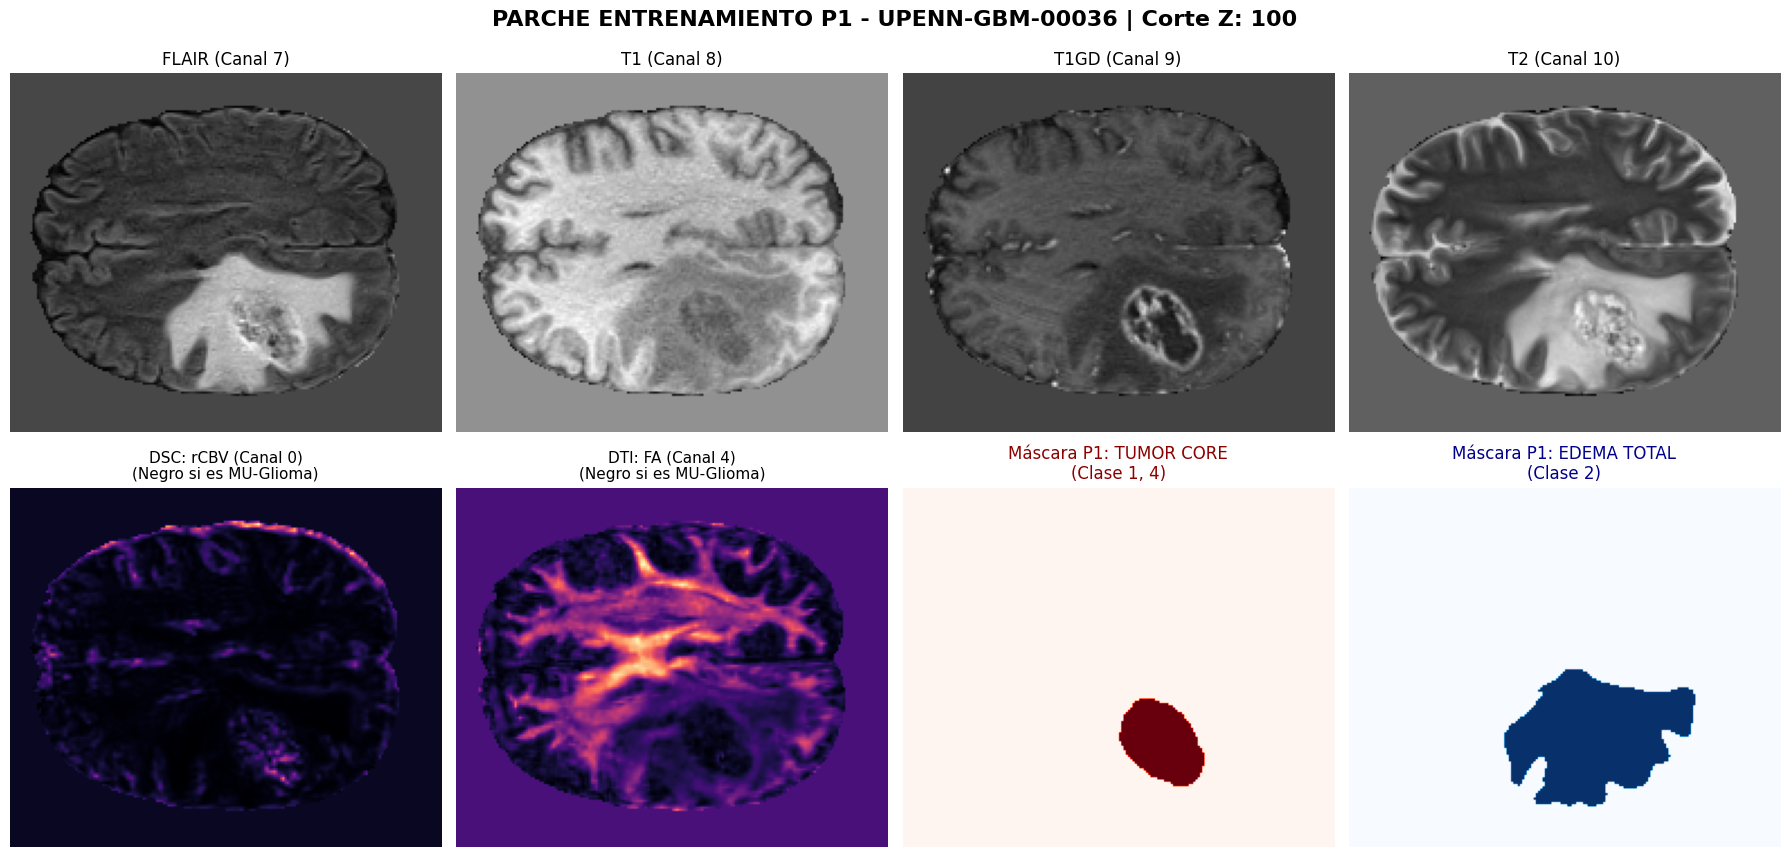

In [13]:

# 1. Definir Rutas (Ajusta estas a tus directorios reales del P1)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 1  # Pipeline 1 (Tumor Core vs Edema Total)

# Definir el paciente exacto que queremos buscar
# ID_BUSCADO = "PatientID_0010"  
ID_BUSCADO = "UPENN-GBM-00036" 

# 2. Definir las transformaciones de PRUEBA DE ENTRENAMIENTO
roi = (128, 128, 64)
test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de Canales a 11
    ImputeMissingChannelsd(keys=["image"]),
    
    # Dropout (0.0 para ver los datos reales en la gráfica sin apagarlos)
    RandModalityDropoutd(keys=["image"], prob=0.5),
    
    # Formateo de Etiquetas PARA PIPELINE 1 (Tumor Core y Edema Total)
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # Recorte inteligente con garantía matemática (Paso previo necesario)
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # Muestreo Balanceado: Extrae el parche real de 128x128x64 que verá la red
    transforms.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 64),
        pos=1,          
        neg=1,          
        num_samples=1,  
        image_key="image",
        image_threshold=0,
    )
])

val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # 1. Unificación de canales (sin dropout para evaluar todo el potencial)
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # 2. Recorte inteligente: Quita el aire negro, garantiza divisibilidad
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # (NOTA: No incluimos recortes aleatorios aquí para que sliding_window_inference 
    # evalúe el volumen completo del cerebro)
        
    # 3. Normalización final
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

myset=val_transform
# 3. Instanciar el Dataset Unificado
print("Inicializando dataset de prueba para P1...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=myset
)

# 4. Buscar el índice del paciente deseado
indice_encontrado = None
ruta_encontrada = ""

for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        ruta_encontrada = data_dict["label"]
        break

# 5. Visualización del Parche Resultante
if indice_encontrado is not None:
    print(f"\n¡Éxito! Paciente '{ID_BUSCADO}' encontrado en el índice [{indice_encontrado}].")
    print(f"Cargando ground truth desde: {ruta_encontrada}")
    
    # EXTRAER EL CASO: [0] porque RandCrop devuelve una lista de diccionarios
    if myset == val_transform:
        caso_especifico = test_set[indice_encontrado]#[0]
    else:
        caso_especifico = test_set[indice_encontrado][0]

    imagen = caso_especifico["image"]   # Shape: [11, 128, 128, 64]
    etiqueta = caso_especifico["label"] # Shape: [2, 128, 128, 64]
    
    print(f"\nForma del tensor de imagen final: {imagen.shape}")
    print(f"Forma del tensor de etiqueta final: {etiqueta.shape}")
    
    # El corte central del parche ahora siempre será 32 (la mitad de 64)
    if myset == val_transform:
        corte_z = 100 #imagen.shape[-1] // 2
    else:
        corte_z = 32 #imagen.shape[-1] // 2

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f'PARCHE ENTRENAMIENTO P1 - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16, fontweight='bold')

    # Fila 1: Modalidades Estructurales (Índices 7 al 10)
    nombres_estructurales = ['FLAIR (Canal 7)', 'T1 (Canal 8)', 'T1GD (Canal 9)', 'T2 (Canal 10)']
    for i, ax in enumerate(axes[0]):
        canal_idx = i + 7
        ax.imshow(imagen[canal_idx, :, :, corte_z].numpy(), cmap="gray")
        ax.set_title(nombres_estructurales[i], fontsize=12)
        ax.axis("off")

    # Fila 2: Control de Imputación y Máscaras Pipeline 1
    axes[1, 0].imshow(imagen[0, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 0].set_title('DSC: rCBV (Canal 0)\n(Negro si es MU-Glioma)', fontsize=11)
    axes[1, 0].axis("off")

    axes[1, 1].imshow(imagen[4, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 1].set_title('DTI: FA (Canal 4)\n(Negro si es MU-Glioma)', fontsize=11)
    axes[1, 1].axis("off")

    # Máscaras del PIPELINE 1 (Aquí cambia el significado de los colores)
    axes[1, 2].imshow(etiqueta[0, :, :, corte_z].numpy(), cmap="Reds")
    axes[1, 2].set_title('Máscara P1: TUMOR CORE\n(Clase 1, 4)', fontsize=12, color='darkred')
    axes[1, 2].axis("off")

    axes[1, 3].imshow(etiqueta[1, :, :, corte_z].numpy(), cmap="Blues")
    axes[1, 3].set_title('Máscara P1: EDEMA TOTAL\n(Clase 2)', fontsize=12, color='darkblue')
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(f"\n❌ Error: El paciente '{ID_BUSCADO}' no se encuentra en el dataset cargado.")

Inicializando dataset de prueba...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 2)
[TRAIN] Cargados 190 casos de MU-Glioma Post (Pipeline 2)

¡Éxito! Paciente 'PatientID_0010' encontrado en el índice [134].
Cargando ground truth desde: ./Dataset/MU_glioma/train/PatientID_0010/Timepoint_4/PatientID_0010_Timepoint_4_tumorMask_2.nii.gz

Forma del tensor de imagen final: torch.Size([11, 160, 192, 160])
Forma del tensor de etiqueta final: torch.Size([2, 160, 192, 160])


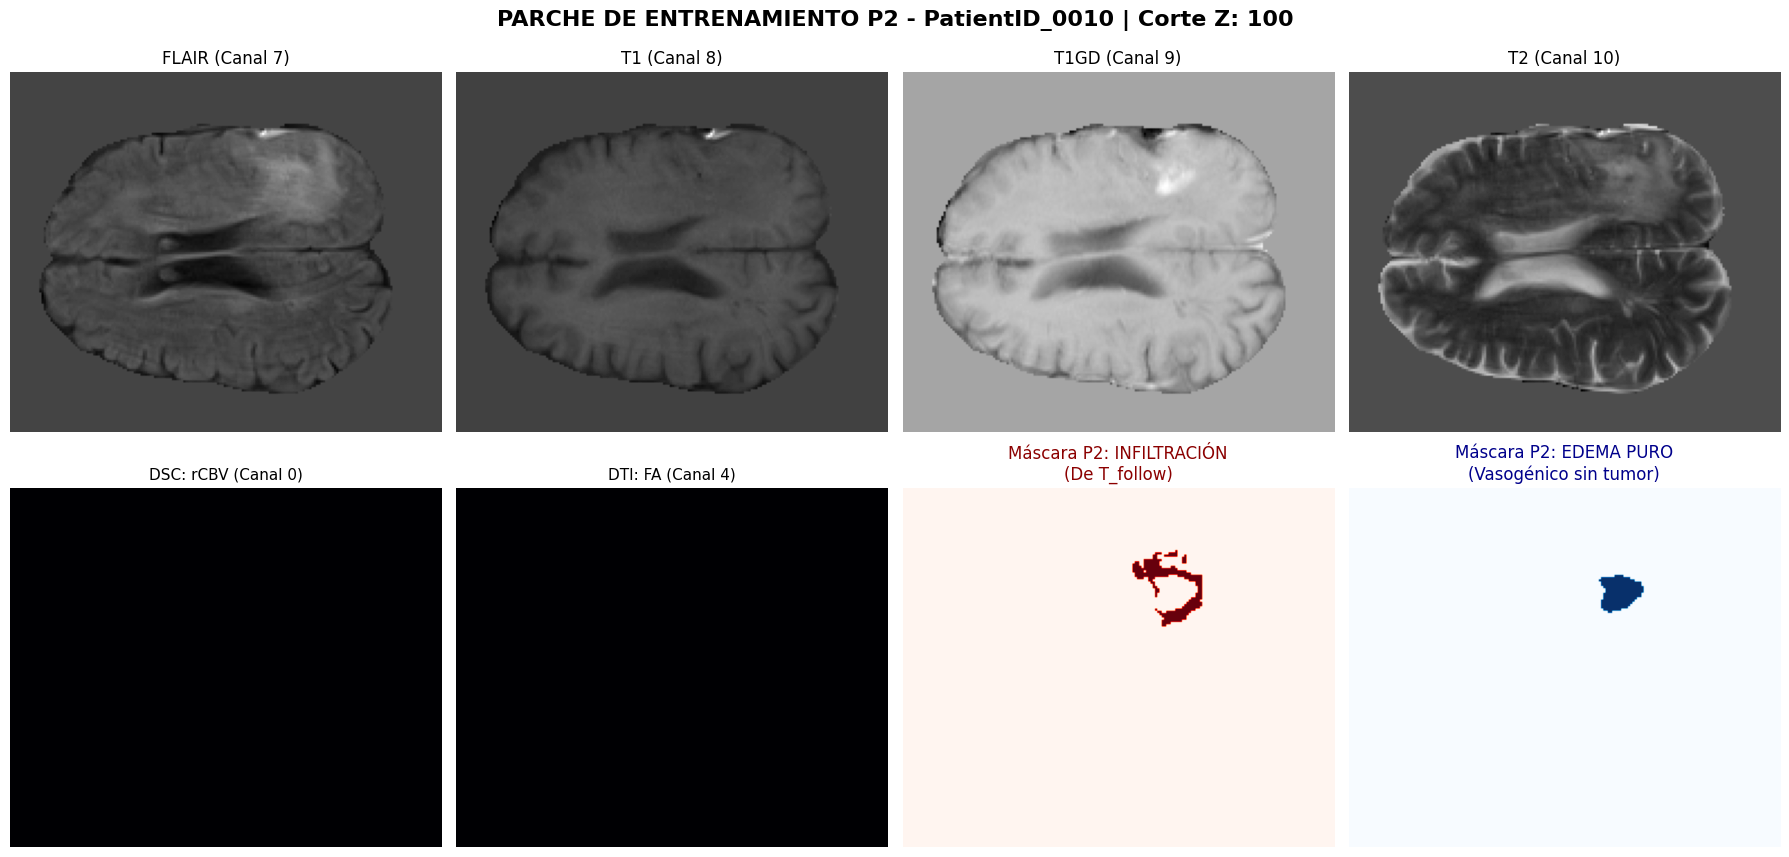

In [4]:
# 1. Definir Rutas (Ajusta estas a tus directorios reales)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 2  # Pipeline 2 (Infiltración vs Edema Puro)

# Definir el paciente exacto que queremos buscar
# ID_BUSCADO = "UPENN-GBM-00036" 
ID_BUSCADO = "PatientID_0010" 

# 2. Definir las transformaciones de PRUEBA DE ENTRENAMIENTO
# (Simulamos exactamente lo que verá la red en el paso forward)
test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de Canales a 11
    ImputeMissingChannelsd(keys=["image"]),
    
    # Dropout (0.0 para ver los datos reales en la gráfica)
    RandModalityDropoutd(keys=["image"], prob=0.5),
    
    # Formateo de Etiquetas PARA PIPELINE 2
    ConvertToMultiChannelPipeline2_Experimento_d(keys=["label"]),
    
    # Recorte inteligente con garantía de divisibilidad (Paso previo necesario)
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # Muestreo Balanceado: Extrae el parche real de 128x128x64 que verá la red
    transforms.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 64),
        pos=1,          
        neg=1,          
        num_samples=1,  
        image_key="image",
        image_threshold=0,
    )
])

val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # 1. Unificación de canales (sin dropout para evaluar todo el potencial)
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline2_Experimento_d(keys=["label"]),
    
    # 2. Recorte inteligente: Quita el aire negro, garantiza divisibilidad
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # (NOTA: No incluimos recortes aleatorios aquí para que sliding_window_inference 
    # evalúe el volumen completo del cerebro)
        
    # 3. Normalización final
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

myset = val_transform
# 3. Instanciar el Dataset Unificado
print("Inicializando dataset de prueba...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=myset
)

# 4. Buscar el índice del paciente deseado
indice_encontrado = None
ruta_encontrada = ""

for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        ruta_encontrada = data_dict["label"]
        break

# 5. Visualización del Parche Resultante
if indice_encontrado is not None:
    print(f"\n¡Éxito! Paciente '{ID_BUSCADO}' encontrado en el índice [{indice_encontrado}].")
    print(f"Cargando ground truth desde: {ruta_encontrada}")
    
    # EXTRAER EL CASO: Notar el [0] al final porque RandCrop devuelve una lista
    if myset == val_transform:
        caso_especifico = test_set[indice_encontrado]#[0]
    else:   
        caso_especifico = test_set[indice_encontrado][0]
    
    imagen = caso_especifico["image"]   # Shape esperado: [11, 128, 128, 64]
    etiqueta = caso_especifico["label"] # Shape esperado: [2, 128, 128, 64]
    
    print(f"\nForma del tensor de imagen final: {imagen.shape}")
    print(f"Forma del tensor de etiqueta final: {etiqueta.shape}")
    
    # El corte central del parche ahora será 32 (la mitad de 64)
    if myset == val_transform:
        corte_z = 100 #imagen.shape[-1] // 2
    else:
        corte_z = 32 #imagen.shape[-1] // 2

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f'PARCHE DE ENTRENAMIENTO P2 - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16, fontweight='bold')

    # Fila 1: Modalidades Estructurales (Índices 7 al 10)
    nombres_estructurales = ['FLAIR (Canal 7)', 'T1 (Canal 8)', 'T1GD (Canal 9)', 'T2 (Canal 10)']
    for i, ax in enumerate(axes[0]):
        canal_idx = i + 7
        ax.imshow(imagen[canal_idx, :, :, corte_z].numpy(), cmap="gray")
        ax.set_title(nombres_estructurales[i], fontsize=12)
        ax.axis("off")

    # Fila 2: Control de Imputación y Máscaras Pipeline 2
    axes[1, 0].imshow(imagen[0, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 0].set_title('DSC: rCBV (Canal 0)', fontsize=11)
    axes[1, 0].axis("off")

    axes[1, 1].imshow(imagen[4, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 1].set_title('DTI: FA (Canal 4)', fontsize=11)
    axes[1, 1].axis("off")

    # Máscaras del PIPELINE 2
    axes[1, 2].imshow(etiqueta[0, :, :, corte_z].numpy(), cmap="Reds")
    axes[1, 2].set_title('Máscara P2: INFILTRACIÓN\n(De T_follow)', fontsize=12, color='darkred')
    axes[1, 2].axis("off")

    axes[1, 3].imshow(etiqueta[1, :, :, corte_z].numpy(), cmap="Blues")
    axes[1, 3].set_title('Máscara P2: EDEMA PURO\n(Vasogénico sin tumor)', fontsize=12, color='darkblue')
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(f"\n❌ Error: El paciente '{ID_BUSCADO}' no se encuentra en el dataset cargado.")

## Pruebas de inferencia pipeline1

In [ ]:
import os
import torch
from monai import transforms
from monai.networks.nets import SwinUNETR

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    ConvertToMultiChannelPipeline2d, ConvertToMultiChannelPipeline1d
)

# 1. Definir Rutas (Ajustadas al Pipeline 2)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 1

# Ruta a tus mejores pesos de la Fase 1
MODEL_WEIGHTS_PATH = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt"
roi = (128, 128, 64)

# 2. Transformaciones de Validación (Cerebro Completo)
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de los 11 canales
    ImputeMissingChannelsd(keys=["image"]),
    
    # Mapeo: Canal 0 -> Tumor Core | Canal 1 -> Edema Total
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # # Recorte del fondo garantizando divisibilidad por 32
    # transforms.CropForegroundd(
    #     keys=["image", "label"], 
    #     source_key="image",
    #     margin=5,
    #     k_divisible=32,
    #     allow_smaller=False
    # ),
        
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# 3. Instanciar Dataset
print(f"Cargando Dataset para Pipeline {PIPELINE}...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=val_transform
)

# 4. Cargar Modelo SwinUNETR
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SwinUNETR(
    img_size=roi,
    in_channels=11,  
    out_channels=2,  # [Tumor Core, Edema Total]
    feature_size=48,
    use_checkpoint=True,
)

if os.path.exists(MODEL_WEIGHTS_PATH):
    checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"¡Pesos de Pipeline 1 cargados desde {MODEL_WEIGHTS_PATH}!")
else:
    print("⚠️ No se encontraron los pesos. Verificando ruta...")

model.to(device)
model.eval()
print("\nSetup listo para inferencia en Pipeline 1.")

Cargando Dataset para Pipeline 1...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 1)
[TRAIN] Cargados 273 casos de MU-Glioma Post (Pipeline 1)


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


¡Pesos de Pipeline 1 cargados desde ./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt!

Setup listo para inferencia en Pipeline 1.


¡Evaluando paciente 'UPENN-GBM-00352'!
Realizando inferencia con sliding_window_inference...
Mostrando corte Z: 78 (Z-slice con mayor área tumoral)


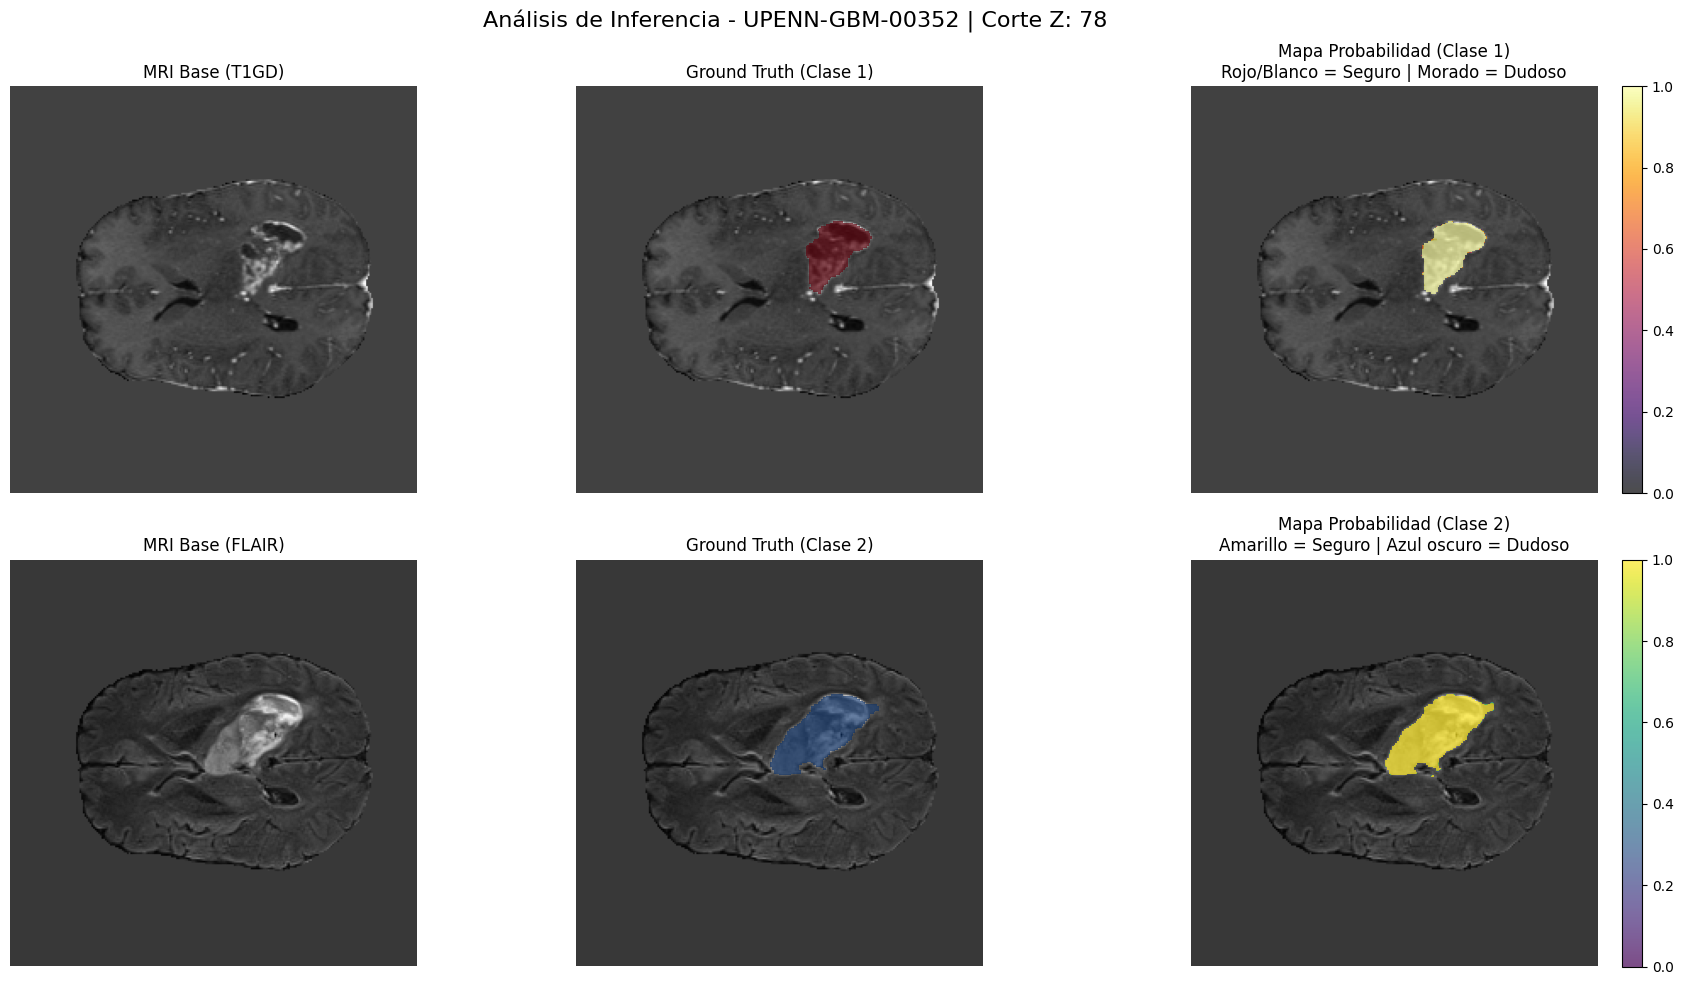

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference

# 1. Configuración de búsqueda e inferencia
ID_BUSCADO = "UPENN-GBM-00352"  # Cambia al ID que quieras evaluar
# ID_BUSCADO = "PatientID_0150" 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.eval()  # Asegurarnos que el modelo está en modo evaluación

# Buscar el índice
indice_encontrado = None
for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        break

if indice_encontrado is not None:
    print(f"¡Evaluando paciente '{ID_BUSCADO}'!")
    
    # 2. Cargar datos y enviar a GPU
    # Recordar que si usamos RandCropByPosNegLabeld en train_transform, devuelve lista.
    # En val_transform (cerebro completo) no devuelve lista. 
    # Hacemos un manejo seguro para ambos casos:
    datos = test_set[indice_encontrado]
    if isinstance(datos, list):
        datos = datos[0]
        
    imagen = datos["image"].unsqueeze(0).to(device) # Añadir dimensión Batch -> [1, 11, H, W, D]
    etiqueta = datos["label"].unsqueeze(0).to(device) # -> [1, 2, H, W, D]
    
    # 3. Ejecutar Inferencia (Sliding Window)
    print("Realizando inferencia con sliding_window_inference...")
    with torch.no_grad():
        # Obtenemos los logits crudos (valores sin normalizar entre -inf y +inf)
        logits = sliding_window_inference(
            inputs=imagen,
            roi_size=(128, 128, 64),
            sw_batch_size=2,
            predictor=model,
            overlap=0.5
        )
        # Aplicar Sigmoide para obtener probabilidades reales entre 0.0 y 1.0
        probabilidades = torch.sigmoid(logits)

    # 4. Bajar a CPU y convertir a Numpy para Matplotlib
    img_np = imagen[0].cpu().numpy()
    gt_np = etiqueta[0].cpu().numpy()
    prob_np = probabilidades[0].cpu().numpy()
    
    # 5. Encontrar el corte Z con más tumor para que la visualización valga la pena
    suma_por_corte = np.sum(gt_np[0] + gt_np[1], axis=(0, 1))
    corte_z = np.argmax(suma_por_corte)
    if suma_por_corte[corte_z] == 0:
        corte_z = img_np.shape[-1] // 2 # Si no hay tumor, mostrar el centro
        
    print(f"Mostrando corte Z: {corte_z} (Z-slice con mayor área tumoral)")

    # 6. Visualización
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Análisis de Inferencia - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16)

    # --- FILA 1: CANAL 0 (Tumor Core o Infiltración) ---
    # Imagen Estructural de Fondo (T1GD suele ser el canal 9 en tu setup de 11 canales)
    t1gd_bg = img_np[9, :, :, corte_z]
    
    # 1.1 Resonancia Base
    axes[0, 0].imshow(t1gd_bg, cmap="gray")
    axes[0, 0].set_title('MRI Base (T1GD)')
    axes[0, 0].axis('off')

    # 1.2 Ground Truth
    axes[0, 1].imshow(t1gd_bg, cmap="gray")
    # Superponemos la máscara real con alpha (transparencia)
    gt_masked_0 = np.ma.masked_where(gt_np[0, :, :, corte_z] == 0, gt_np[0, :, :, corte_z])
    axes[0, 1].imshow(gt_masked_0, cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[0, 1].set_title('Ground Truth (Clase 1)')
    axes[0, 1].axis('off')

    # 1.3 Mapa de Probabilidad (Predicción de la Red)
    axes[0, 2].imshow(t1gd_bg, cmap="gray")
    prob_masked_0 = np.ma.masked_where(prob_np[0, :, :, corte_z] < 0.05, prob_np[0, :, :, corte_z]) # Ocultar ruido bajísimo
    im0 = axes[0, 2].imshow(prob_masked_0, cmap="inferno", alpha=0.7, vmin=0, vmax=1)
    axes[0, 2].set_title('Mapa Probabilidad (Clase 1)\nRojo/Blanco = Seguro | Morado = Dudoso')
    axes[0, 2].axis('off')
    fig.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)

    # --- FILA 2: CANAL 1 (Edema Total o Edema Vasogénico) ---
    # Imagen Estructural de Fondo (FLAIR suele ser el canal 7)
    flair_bg = img_np[7, :, :, corte_z]

    # 2.1 Resonancia Base
    axes[1, 0].imshow(flair_bg, cmap="gray")
    axes[1, 0].set_title('MRI Base (FLAIR)')
    axes[1, 0].axis('off')

    # 2.2 Ground Truth
    axes[1, 1].imshow(flair_bg, cmap="gray")
    gt_masked_1 = np.ma.masked_where(gt_np[1, :, :, corte_z] == 0, gt_np[1, :, :, corte_z])
    axes[1, 1].imshow(gt_masked_1, cmap="Blues", alpha=0.6, vmin=0, vmax=1)
    axes[1, 1].set_title('Ground Truth (Clase 2)')
    axes[1, 1].axis('off')

    # 2.3 Mapa de Probabilidad (Predicción de la Red)
    axes[1, 2].imshow(flair_bg, cmap="gray")
    prob_masked_1 = np.ma.masked_where(prob_np[1, :, :, corte_z] < 0.05, prob_np[1, :, :, corte_z])
    im1 = axes[1, 2].imshow(prob_masked_1, cmap="viridis", alpha=0.7, vmin=0, vmax=1)
    axes[1, 2].set_title('Mapa Probabilidad (Clase 2)\nAmarillo = Seguro | Azul oscuro = Dudoso')
    axes[1, 2].axis('off')
    fig.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    
else:
    print(f"Paciente {ID_BUSCADO} no encontrado.")

## Evaluacion pipeline2

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.networks.nets import SwinUNETR

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    ConvertToMultiChannelPipeline2d, ConvertToMultiChannelPipeline1d, ConvertToMultiChannelPipeline2_Experimento_d
)

# 1. SETUP DE DATOS Y MODELO (Ajustado a Pipeline 2)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 2
MODEL_WEIGHTS_PATH = "./Dataset_Output/pipe2/expert-jazz-7/model_best.pt"
roi = (128, 128, 64)
ID_BUSCADO = "UPENN-GBM-00134" 
# ID_BUSCADO = "PatientID_0093" 

# Transformación de Validación SIN RECORTE
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline2_Experimento_d(keys=["label"]),
    # Se eliminó CropForegroundd para mantener dimensiones originales 240x240x155
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# Instanciar Dataset y cargar Modelo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_set = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section="val", pipeline=PIPELINE, transform=val_transform)

model = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
if os.path.exists(MODEL_WEIGHTS_PATH):
    checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print("Pesos P2 cargados.")
model.eval()

# 2. BÚSQUEDA E INFERENCIA
indice_encontrado = next((i for i, d in enumerate(test_set.data) if ID_BUSCADO in d["label"]), None)

if indice_encontrado is not None:
    # Cargar caso completo (al no haber recorte, el tensor será de tamaño original)
    datos = test_set[indice_encontrado]
    imagen = datos["image"].unsqueeze(0).to(device) # [1, 11, H, W, D]
    etiqueta = datos["label"].unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = sliding_window_inference(imagen, roi, sw_batch_size=2, predictor=model, overlap=0.5)
        probabilidades = torch.sigmoid(logits)

    img_np = imagen[0].cpu().numpy()
    gt_np = etiqueta[0].cpu().numpy()
    prob_np = probabilidades[0].cpu().numpy()
    
    # Corte Z óptimo (donde hay más infiltración)
    corte_z = np.argmax(np.sum(gt_np[0], axis=(0, 1)))
    # corte_z=90
    
    # 3. VISUALIZACIÓN
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Inferencia P2 (Original Size) - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16)

    # Canal 0: Infiltración (Fondo T1GD)
    bg0 = img_np[9, :, :, corte_z]
    axes[0, 0].imshow(bg0, cmap="gray"); axes[0, 0].set_title('T1GD Base'); axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bg0, cmap="gray")
    gt0 = np.ma.masked_where(gt_np[0, :, :, corte_z] == 0, gt_np[0, :, :, corte_z])
    axes[0, 1].imshow(gt0, cmap="Reds", alpha=0.6); axes[0, 1].set_title('GT: Infiltración'); axes[0, 1].axis('off')

    axes[0, 2].imshow(bg0, cmap="gray")
    p0 = np.ma.masked_where(prob_np[0, :, :, corte_z] < 0.1, prob_np[0, :, :, corte_z])
    im0 = axes[0, 2].imshow(p0, cmap="hot", alpha=0.7, vmin=0, vmax=1)
    axes[0, 2].set_title('Probabilidad Infiltración'); axes[0, 2].axis('off')
    fig.colorbar(im0, ax=axes[0, 2])

    # Canal 1: Edema Puro (Fondo FLAIR)
    bg1 = img_np[7, :, :, corte_z]
    axes[1, 0].imshow(bg1, cmap="gray"); axes[1, 0].set_title('FLAIR Base'); axes[1, 0].axis('off')

    axes[1, 1].imshow(bg1, cmap="gray")
    gt1 = np.ma.masked_where(gt_np[1, :, :, corte_z] == 0, gt_np[1, :, :, corte_z])
    axes[1, 1].imshow(gt1, cmap="Blues", alpha=0.6); axes[1, 1].set_title('GT: TC'); axes[1, 1].axis('off')

    axes[1, 2].imshow(bg1, cmap="gray")
    p1 = np.ma.masked_where(prob_np[1, :, :, corte_z] < 0.1, prob_np[1, :, :, corte_z])
    im1 = axes[1, 2].imshow(p1, cmap="winter", alpha=0.7, vmin=0, vmax=1)
    axes[1, 2].set_title('Probabilidad TC'); axes[1, 2].axis('off')
    fig.colorbar(im1, ax=axes[1, 2])

    plt.tight_layout(); plt.show()



In [ ]:
if indice_encontrado is not None:
       
    # Corte Z óptimo (donde hay más infiltración)
    # corte_z = np.argmax(np.sum(gt_np[0], axis=(0, 1)))
    corte_z=60
    
    # 3. VISUALIZACIÓN
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Inferencia P2 (Original Size) - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16)

    # Canal 0: Infiltración (Fondo T1GD)
    bg0 = img_np[9, :, :, corte_z]
    axes[0, 0].imshow(bg0, cmap="gray"); axes[0, 0].set_title('T1GD Base'); axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bg0, cmap="gray")
    gt0 = np.ma.masked_where(gt_np[0, :, :, corte_z] == 0, gt_np[0, :, :, corte_z])
    axes[0, 1].imshow(gt0, cmap="Reds", alpha=0.6); axes[0, 1].set_title('GT: Infiltración'); axes[0, 1].axis('off')

    axes[0, 2].imshow(bg0, cmap="gray")
    p0 = np.ma.masked_where(prob_np[0, :, :, corte_z] < 0.1, prob_np[0, :, :, corte_z])
    im0 = axes[0, 2].imshow(p0, cmap="hot", alpha=0.7, vmin=0, vmax=1)
    axes[0, 2].set_title('Probabilidad Infiltración'); axes[0, 2].axis('off')
    fig.colorbar(im0, ax=axes[0, 2])

    # Canal 1: Edema Puro (Fondo FLAIR)
    bg1 = img_np[7, :, :, corte_z]
    axes[1, 0].imshow(bg1, cmap="gray"); axes[1, 0].set_title('FLAIR Base'); axes[1, 0].axis('off')

    axes[1, 1].imshow(bg1, cmap="gray")
    gt1 = np.ma.masked_where(gt_np[1, :, :, corte_z] == 0, gt_np[1, :, :, corte_z])
    axes[1, 1].imshow(gt1, cmap="Blues", alpha=0.6); axes[1, 1].set_title('GT: TC'); axes[1, 1].axis('off')

    axes[1, 2].imshow(bg1, cmap="gray")
    p1 = np.ma.masked_where(prob_np[1, :, :, corte_z] < 0.1, prob_np[1, :, :, corte_z])
    im1 = axes[1, 2].imshow(p1, cmap="winter", alpha=0.7, vmin=0, vmax=1)
    axes[1, 2].set_title('Probabilidad TC'); axes[1, 2].axis('off')
    fig.colorbar(im1, ax=axes[1, 2])

    plt.tight_layout(); plt.show()

## Visulaizar todos los cortes

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from monai.inferers import sliding_window_inference
from monai import transforms
from monai.networks.nets import SwinUNETR

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    ConvertToMultiChannelPipeline2d, ConvertToMultiChannelPipeline1d, ConvertToMultiChannelPipeline2_Experimento_d
)

# Comando mágico de Jupyter para mostrar los gráficos correctamente en línea
%matplotlib inline

# 1. SETUP DE DATOS Y MODELO (Ajustado a Pipeline 2)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 2
MODEL_WEIGHTS_PATH = "./Dataset_Output/pipe2/expert-jazz-7/model_best.pt"
roi = (128, 128, 64)
ID_BUSCADO = "UPENN-GBM-00055" 
# ID_BUSCADO = "PatientID_0038" 

# Transformación de Validación SIN RECORTE
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline2_Experimento_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# Instanciar Dataset y cargar Modelo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_set = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section="val", pipeline=PIPELINE, transform=val_transform)

model = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
if os.path.exists(MODEL_WEIGHTS_PATH):
    checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print("Pesos P2 cargados.")
model.eval()

# 2. BÚSQUEDA E INFERENCIA (Solo se ejecuta una vez)
indice_encontrado = next((i for i, d in enumerate(test_set.data) if ID_BUSCADO in d["label"]), None)

if indice_encontrado is not None:
    # Cargar caso completo
    datos = test_set[indice_encontrado]
    imagen = datos["image"].unsqueeze(0).to(device) # [1, 11, H, W, D]
    etiqueta = datos["label"].unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = sliding_window_inference(imagen, roi, sw_batch_size=2, predictor=model, overlap=0.5)
        probabilidades = torch.sigmoid(logits)

    img_np = imagen[0].cpu().numpy()
    gt_np = etiqueta[0].cpu().numpy()
    prob_np = probabilidades[0].cpu().numpy()
    
    # Obtener el número total de cortes Z para configurar el límite del slider
    max_z = img_np.shape[3] - 1
    
    # Corte Z óptimo por defecto (donde hay más infiltración)
    corte_z_optimo = int(np.argmax(np.sum(gt_np[0], axis=(0, 1))))
    
    # 3. FUNCIÓN DE VISUALIZACIÓN INTERACTIVA
    def plot_slices(corte_z):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'Inferencia P2 (Original Size) - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16)

        # Canal 0: Infiltración (Fondo T1GD)
        bg0 = img_np[9, :, :, corte_z]
        axes[0, 0].imshow(bg0, cmap="gray"); axes[0, 0].set_title('T1GD Base'); axes[0, 0].axis('off')
        
        axes[0, 1].imshow(bg0, cmap="gray")
        gt0 = np.ma.masked_where(gt_np[0, :, :, corte_z] == 0, gt_np[0, :, :, corte_z])
        axes[0, 1].imshow(gt0, cmap="Reds", alpha=0.6); axes[0, 1].set_title('GT: Infiltración'); axes[0, 1].axis('off')

        axes[0, 2].imshow(bg0, cmap="gray")
        p0 = np.ma.masked_where(prob_np[0, :, :, corte_z] < 0.1, prob_np[0, :, :, corte_z])
        im0 = axes[0, 2].imshow(p0, cmap="hot", alpha=0.7, vmin=0, vmax=1)
        axes[0, 2].set_title('Probabilidad Infiltración'); axes[0, 2].axis('off')
        fig.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)

        # Canal 1: Edema Puro (Fondo FLAIR)
        bg1 = img_np[7, :, :, corte_z]
        axes[1, 0].imshow(bg1, cmap="gray"); axes[1, 0].set_title('FLAIR Base'); axes[1, 0].axis('off')

        axes[1, 1].imshow(bg1, cmap="gray")
        gt1 = np.ma.masked_where(gt_np[1, :, :, corte_z] == 0, gt_np[1, :, :, corte_z])
        axes[1, 1].imshow(gt1, cmap="Blues", alpha=0.6); axes[1, 1].set_title('GT: TC'); axes[1, 1].axis('off')

        axes[1, 2].imshow(bg1, cmap="gray")
        p1 = np.ma.masked_where(prob_np[1, :, :, corte_z] < 0.1, prob_np[1, :, :, corte_z])
        im1 = axes[1, 2].imshow(p1, cmap="winter", alpha=0.7, vmin=0, vmax=1)
        axes[1, 2].set_title('Probabilidad TC'); axes[1, 2].axis('off')
        fig.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    # 4. CREAR EL WIDGET INTERACTIVO
    slider = widgets.IntSlider(min=0, max=max_z, step=1, value=corte_z_optimo, description='Corte Z:')
    widgets.interact(plot_slices, corte_z=slider)
    
else:
    print(f"ID {ID_BUSCADO} no encontrado.")

[VAL] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[VAL] Cargados 21 casos de MU-Glioma Post (Pipeline 2)


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Pesos P2 cargados.


interactive(children=(IntSlider(value=90, description='Corte Z:', max=154), Output()), _dom_classes=('widget-i…

# Obtener metricas

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader, decollate_batch
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# --- TUS IMPORTACIONES PERSONALIZADAS ---
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    ConvertToMultiChannelPipeline2d,               # Variante A
    ConvertToMultiChannelPipeline2_Experimento_d,  # Variante B
    ConvertToMultiChannel3Tier_d                   # Variante C
)

In [2]:
# ==========================================
# 1. SELECCIÓN DEL EXPERIMENTO Y DATASET
# ==========================================
# Opciones válidas: "VARIANTE_A", "VARIANTE_B", "VARIANTE_C"
# VARIANTE_A: Extended Target vs Whole Abnormal (2 canales)
# VARIANTE_B: Infiltración Pura + Core Anchor (2 canales)
# VARIANTE_C: 3-Tier Nested Solids (3 canales)

EXPERIMENTO_ACTUAL = "VARIANTE_B"  # <--- CAMBIA ESTO PARA EVALUAR OTRO MODELO

# Rutas y Partición
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PARTICION = "val" # Cambia a "test" cuando quieras la evaluación final a ciegas

# Ruta del modelo a evaluar
MODEL_WEIGHTS = f"./Dataset_Output/pipe2/expert-jazz-7/model_best.pt"  # Asegúrate de que esta ruta sea correcta para cada variante

# Parámetros de Inferencia
roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
# ==========================================
# 2. CONFIGURACIÓN DINÁMICA SEGÚN VARIANTE
# ==========================================
if EXPERIMENTO_ACTUAL == "VARIANTE_A":
    out_channels = 2
    TransformClass = ConvertToMultiChannelPipeline2d
    print("Modo: VARIANTE A (Extended vs Whole) | 2 Canales")
    
elif EXPERIMENTO_ACTUAL == "VARIANTE_B":
    out_channels = 2
    TransformClass = ConvertToMultiChannelPipeline2_Experimento_d
    print("Modo: VARIANTE B (Infiltración + Core Anchor) | 2 Canales")
    
elif EXPERIMENTO_ACTUAL == "VARIANTE_C":
    out_channels = 3
    TransformClass = ConvertToMultiChannel3Tier_d
    print("Modo: VARIANTE C (Triple Muñeca Rusa - 3-Tier) | 3 Canales")
else:
    raise ValueError("Experimento no válido.")

# Transformación de Evaluación (Sin aumentaciones ni dropout)
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    TransformClass(keys=["label"]),
    # Sin CropForegroundd para evaluar la imagen completa
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# Cargar Dataset
dataset_eval = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section=PARTICION, 
    pipeline=2, # Siempre pipeline 2 para carga básica
    transform=val_transform
)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)
print(f"Casos a evaluar ({PARTICION}): {len(dataset_eval)}")

Modo: VARIANTE B (Infiltración + Core Anchor) | 2 Canales
[VAL] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[VAL] Cargados 21 casos de MU-Glioma Post (Pipeline 2)
Casos a evaluar (val): 27


In [4]:
# ==========================================
# 3. CARGA DE LA RED NEURONAL
# ==========================================
model = SwinUNETR(
    img_size=roi,
    in_channels=11,
    out_channels=out_channels, # Automático según el experimento
    feature_size=48,
    use_checkpoint=True
).to(device)

if os.path.exists(MODEL_WEIGHTS):
    checkpoint = torch.load(MODEL_WEIGHTS, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"Pesos cargados exitosamente desde: {MODEL_WEIGHTS}")
else:
    print(f"⚠️ ERROR: No se encontró el archivo de pesos en {MODEL_WEIGHTS}")

model.eval()
post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=0.5)

/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Pesos cargados exitosamente desde: ./Dataset_Output/pipe2/expert-jazz-7/model_best.pt


In [5]:
# ==========================================
# 4. BUCLE DE INFERENCIA Y CÁLCULO DE MÉTRICAS
# ==========================================
# Función auxiliar manual para calcular el Dice Score
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc="Evaluando"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device)
        source = batch_data.get("source", ["Desconocido"])[0] # UPENN o MUGLIOMA
        
        # Inferencia
        logits = sliding_window_inference(data, roi, sw_batch_size, model, overlap=infer_overlap)
        
        # Binarización
        pred_tensor = post_pred(post_sigmoid(logits[0]))
        target_tensor = target[0].bool()
        pred_tensor = pred_tensor.bool()
        
        dice_ext_target = np.nan
        dice_infilt_pura = np.nan
        
        # --- EXTRACCIÓN TOPOLÓGICA DEPENDIENDO DEL EXPERIMENTO ---
        
        if EXPERIMENTO_ACTUAL == "VARIANTE_A":
            # [0: Ext Target, 1: Whole Abnormal]
            # Extended Target viene directo en el canal 0
            dice_ext_target = calculate_dice(pred_tensor[0], target_tensor[0])
            # La infiltración pura NO se puede calcular aquí sin tener el Tumor Core previo de P1.
            dice_infilt_pura = np.nan 
            
        elif EXPERIMENTO_ACTUAL == "VARIANTE_B":
            # [0: Infilt Pura, 1: Tumor Core]
            # Infiltración pura viene directa en el canal 0
            dice_infilt_pura = calculate_dice(pred_tensor[0], target_tensor[0])
            # Extended Target se reconstruye sumando lógicamente ambos canales
            pred_ext = pred_tensor[0] | pred_tensor[1]
            gt_ext = target_tensor[0] | target_tensor[1]
            dice_ext_target = calculate_dice(pred_ext, gt_ext)
            # Extracción interna de P2
            pred_infilt_p2 = pred_tensor[0]
            pred_core_p2 = pred_tensor[1]
        
            # Calcular Dice del Core de P2 frente al Ground Truth del Core
            dice_core_interno_p2 = calculate_dice(pred_core_p2, target_tensor[1])
            
        elif EXPERIMENTO_ACTUAL == "VARIANTE_C":
            # [0: Core, 1: Extended Target, 2: Whole Abnormal]
            # Extended Target viene directo en el canal 1
            dice_ext_target = calculate_dice(pred_tensor[1], target_tensor[1])
            # Infiltración pura se calcula restando el Core (0) al Extended (1)
            pred_infilt = pred_tensor[1] & (~pred_tensor[0])
            gt_infilt = target_tensor[1] & (~target_tensor[0])
            dice_infilt_pura = calculate_dice(pred_infilt, gt_infilt)
            
        # Guardar resultados
        nuevo_resultado = {
            "Dataset": source,
            "Dice_Extended_Target": dice_ext_target.item() if isinstance(dice_ext_target, torch.Tensor) else dice_ext_target,
            "Dice_Infilt_Pura": dice_infilt_pura.item() if isinstance(dice_infilt_pura, torch.Tensor) else dice_infilt_pura
        }
        
        # Añadimos el Core interno solo si estamos en la Variante B
        if EXPERIMENTO_ACTUAL == "VARIANTE_B":
            nuevo_resultado["Dice_Core_P2"] = dice_core_interno_p2.item() if isinstance(dice_core_interno_p2, torch.Tensor) else dice_core_interno_p2
            
        resultados.append(nuevo_resultado)

Evaluando: 100%|██████████| 27/27 [01:41<00:00,  3.75s/it]


In [6]:
# ==========================================
# 5. REPORTE ESTADÍSTICO
# ==========================================
df_resultados = pd.DataFrame(resultados)

print(f"\n{'='*70}")
print(f"REPORTE DE EVALUACIÓN: {EXPERIMENTO_ACTUAL}")
print(f"{'='*70}")

# Definimos las columnas base a mostrar
columnas_metricas = ["Dice_Extended_Target", "Dice_Infilt_Pura"]

# Si existe la métrica del Core Interno (Variante B), la añadimos al principio de la lista
if "Dice_Core_P2" in df_resultados.columns:
    columnas_metricas.insert(0, "Dice_Core_P2")

# Promedios Globales
print("\n--- MÉTRICAS GLOBALES ---")
if EXPERIMENTO_ACTUAL == "VARIANTE_A":
    print("Nota: En Variante A no se puede aislar la Infiltración Pura matemáticamente sin el Core.")
    
print(df_resultados[columnas_metricas].mean().to_frame("Dice Medio Global").round(4))

# Promedios por Base de Datos (Muy útil para ver si el modelo tiene sesgos)
print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_resultados.groupby("Dataset")[columnas_metricas].mean().round(4))


REPORTE DE EVALUACIÓN: VARIANTE_B

--- MÉTRICAS GLOBALES ---
                      Dice Medio Global
Dice_Core_P2                     0.8580
Dice_Extended_Target             0.7286
Dice_Infilt_Pura                 0.2977

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Core_P2  Dice_Extended_Target  Dice_Infilt_Pura
Dataset                                                       
MUGLIOMA        0.8388                0.7193            0.2396
UPENN           0.9251                0.7612            0.5009


# Resultados pipelines combinados A

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y MODELOS
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PARTICION = "val" 

# --- RUTAS DE LOS PESOS (Ajusta estas rutas a tus carpetas reales) ---
# Modelo del Pipeline 1 (El que saca 0.90 en Core)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# Modelo del Pipeline 2 Variante A (El que saca 0.737 en Extended Target)
MODEL_P2A_WEIGHTS = "./Dataset_Output/pipe2/ethereal-silence-5/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    # Usamos 3-Tier para tener el GT de: [0: Core, 1: Extended, 2: Whole]
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Especialista en Core)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2A (Especialista en Extended Target)...")
model_p2a = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2a.load_state_dict(torch.load(MODEL_P2A_WEIGHTS, map_location=device)["state_dict"])
model_p2a.eval()

post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=0.5)

# ==========================================
# 4. MOTOR DE INFERENCIA EN CASCADA
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados_cascada = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc="Evaluación en Cascada (P1 + P2)"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        pred_core = pred_p1[0] # Canal 0 es el Tumor Core
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Variante A) ---
        logits_p2a = sliding_window_inference(data, roi, sw_batch_size, model_p2a, overlap=infer_overlap)
        pred_p2a = post_pred(post_sigmoid(logits_p2a[0])).bool()
        pred_extended = pred_p2a[0] # Canal 0 es el Extended Target
        
        # --- EXTRACCIÓN MATEMÁTICA DE INFILTRACIÓN ---
        # Infiltración = Target Extendido (de P2) MENOS Tumor Core (de P1)
        pred_infilt_pura = pred_extended & (~pred_core)
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_infilt_pura = gt_extended & (~gt_core)
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_ext = calculate_dice(pred_extended, gt_extended)
        dice_infilt = calculate_dice(pred_infilt_pura, gt_infilt_pura)
        dice_core = calculate_dice(pred_core, gt_core) # Evaluamos el core de paso
        
        resultados_cascada.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Extended_Target (P2)": dice_ext.item(),
            "Dice_Infilt_Pura (Cascada)": dice_infilt.item()
        })

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_cascada = pd.DataFrame(resultados_cascada)

print(f"\n{'='*60}")
print("REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + P2)")
print(f"{'='*60}")

print("\n--- MÉTRICAS GLOBALES ---")
print(df_cascada.mean(numeric_only=True).to_frame("Dice Medio Global"))

print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_cascada.groupby("Dataset").mean(numeric_only=True))

[VAL] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[VAL] Cargados 21 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Especialista en Core)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2A (Especialista en Extended Target)...


Evaluación en Cascada (P1 + P2): 100%|██████████| 27/27 [03:14<00:00,  7.21s/it]


REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + P2)

--- MÉTRICAS GLOBALES ---
                            Dice Medio Global
Dice_Tumor_Core (P1)                 0.878316
Dice_Extended_Target (P2)            0.739082
Dice_Infilt_Pura (Cascada)           0.134494

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Tumor_Core (P1)  Dice_Extended_Target (P2)  \
Dataset                                                     
MUGLIOMA              0.855059                   0.761018   
UPENN                 0.959713                   0.662306   

          Dice_Infilt_Pura (Cascada)  
Dataset                               
MUGLIOMA                    0.121499  
UPENN                       0.179976  


## Resultados Pipelines combinados B

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y MODELOS
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PARTICION = "val" 

# --- RUTAS DE LOS PESOS DE LA CASCADA DEFINITIVA ---
# Modelo del Pipeline 1 (El especialista en Tumor Core de 0.96)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# Modelo del Pipeline 2 Experimento B (El especialista en Infiltración Anclada)
MODEL_P2B_WEIGHTS = "./Dataset_Output/pipe2/expert-jazz-7/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Iniciando evaluación en: {device}")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    # Usamos 3-Tier para tener el GT de: [0: Core, 1: Extended, 2: Whole]
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Especialista en Core)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2B (expert-jazz-7)...")
model_p2b = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2b.load_state_dict(torch.load(MODEL_P2B_WEIGHTS, map_location=device)["state_dict"])
model_p2b.eval()

post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=0.5)

# ==========================================
# 4. MOTOR DE INFERENCIA EN CASCADA
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados_cascada = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc="Evaluación en Cascada (P1 + expert-jazz-7)"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        # Usamos autocast para ahorrar memoria VRAM
        with torch.cuda.amp.autocast():
            logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        pred_core_p1 = pred_p1[0] # Canal 0 es el Tumor Core maestro
        
        # Limpieza rápida de GPU
        del logits_p1, pred_p1
        torch.cuda.empty_cache()
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Variante B) ---
        with torch.cuda.amp.autocast():
            logits_p2b = sliding_window_inference(data, roi, sw_batch_size, model_p2b, overlap=infer_overlap)
            
        pred_p2b = post_pred(post_sigmoid(logits_p2b[0])).bool()
        pred_infilt_cruda = pred_p2b[0] # Canal 0 es la Infiltración (con posible bleeding)
        
        del logits_p2b, pred_p2b
        torch.cuda.empty_cache()
        
        # --- EXTRACCIÓN MATEMÁTICA EN CASCADA ---
        # 1. Regla de Oro: La Infiltración no puede invadir el Tumor Core
        pred_infilt_final = pred_infilt_cruda & (~pred_core_p1)
        
        # 2. Reconstrucción: Target Extendido = Core (P1) + Infiltración Final (P2 limpia)
        pred_extended_final = pred_core_p1 | pred_infilt_final
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_infilt_pura = gt_extended & (~gt_core)
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_core = calculate_dice(pred_core_p1, gt_core) 
        dice_infilt = calculate_dice(pred_infilt_final, gt_infilt_pura)
        dice_ext = calculate_dice(pred_extended_final, gt_extended)
        
        resultados_cascada.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Infilt_Pura (Cascada)": dice_infilt.item(),
            "Dice_Extended_Target (Cascada)": dice_ext.item()
        })
        
        del data, target, pred_core_p1, pred_infilt_cruda, pred_infilt_final, pred_extended_final
        torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_cascada = pd.DataFrame(resultados_cascada)

print(f"\n{'='*70}")
print("REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + expert-jazz-7)")
print(f"{'='*70}")

# Columnas ordenadas por lógica biológica
columnas = ["Dice_Tumor_Core (P1)", "Dice_Infilt_Pura (Cascada)", "Dice_Extended_Target (Cascada)"]

print("\n--- MÉTRICAS GLOBALES ---")
print(df_cascada[columnas].mean(numeric_only=True).to_frame("Dice Medio Global").round(4))

print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_cascada.groupby("Dataset")[columnas].mean(numeric_only=True).round(4))

Iniciando evaluación en: cuda:0
[VAL] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[VAL] Cargados 21 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Especialista en Core)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2B (expert-jazz-7)...


Evaluación en Cascada (P1 + expert-jazz-7): 100%|██████████| 27/27 [02:18<00:00,  5.12s/it]


REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + expert-jazz-7)

--- MÉTRICAS GLOBALES ---
                                Dice Medio Global
Dice_Tumor_Core (P1)                       0.8783
Dice_Infilt_Pura (Cascada)                 0.2941
Dice_Extended_Target (Cascada)             0.7230

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Tumor_Core (P1)  Dice_Infilt_Pura (Cascada)  \
Dataset                                                      
MUGLIOMA                0.8550                      0.2361   
UPENN                   0.9597                      0.4975   

          Dice_Extended_Target (Cascada)  
Dataset                                   
MUGLIOMA                          0.7110  
UPENN                             0.7649  


In [1]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y MODELOS
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PARTICION = "val" 

# --- RUTAS DE LOS PESOS DE LA CASCADA DEFINITIVA ---
# Modelo del Pipeline 1 (El especialista en Tumor Core de 0.96)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# Modelo del Pipeline 2 Experimento B (El especialista en Infiltración Anclada)
MODEL_P2B_WEIGHTS = "./Dataset_Output/pipe2/expert-jazz-7/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Iniciando evaluación en: {device}")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    # Usamos 3-Tier para tener el GT de: [0: Core, 1: Extended, 2: Whole]
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Especialista en Core)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2B (expert-jazz-7)...")
model_p2b = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2b.load_state_dict(torch.load(MODEL_P2B_WEIGHTS, map_location=device)["state_dict"])
model_p2b.eval()

post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=0.5)

# ==========================================
# 4. MOTOR DE INFERENCIA EN CASCADA
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados_cascada = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc="Evaluación en Cascada (P1 + expert-jazz-7)"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        with torch.cuda.amp.autocast():
            logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        pred_core_p1 = pred_p1[0] # El Maestro del Core
        
        del logits_p1, pred_p1
        torch.cuda.empty_cache()
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Variante B) ---
        with torch.cuda.amp.autocast():
            logits_p2b = sliding_window_inference(data, roi, sw_batch_size, model_p2b, overlap=infer_overlap)
        pred_p2b = post_pred(post_sigmoid(logits_p2b[0])).bool()
        
        # Extraemos ambas clases de P2
        pred_infilt_p2 = pred_p2b[0] 
        pred_core_p2 = pred_p2b[1] 
        
        del logits_p2b, pred_p2b
        torch.cuda.empty_cache()
        
        # ====================================================
        # LA EXTRACCIÓN MATEMÁTICA CORREGIDA (Sin Agujeros Negros)
        # ====================================================
        
        # 1. P2 es el experto del borde exterior. Juntamos todo lo que detectó.
        # Esto recupera los vóxeles que P2 asignó al Core por error.
        pred_target_extendido_p2 = pred_infilt_p2 | pred_core_p2
        
        # 2. El bisturí: Al Target Extendido de P2 le restamos el Core Maestro de P1
        # Todo el tejido "en disputa" se salva y se convierte en Infiltración
        pred_infilt_final = pred_target_extendido_p2 & (~pred_core_p1)
        
        # 3. La reconstrucción final
        pred_extended_final = pred_core_p1 | pred_infilt_final
        # ====================================================
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_infilt_pura = gt_extended & (~gt_core)
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_core = calculate_dice(pred_core_p1, gt_core) 
        dice_infilt = calculate_dice(pred_infilt_final, gt_infilt_pura)
        dice_ext = calculate_dice(pred_extended_final, gt_extended)
        
        resultados_cascada.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Infilt_Pura (Cascada)": dice_infilt.item(),
            "Dice_Extended_Target (Cascada)": dice_ext.item()
        })
        
        del data, target, pred_core_p1, pred_infilt_p2, pred_infilt_final, pred_extended_final
        torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_cascada = pd.DataFrame(resultados_cascada)

print(f"\n{'='*70}")
print("REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + expert-jazz-7)")
print(f"{'='*70}")

# Columnas ordenadas por lógica biológica
columnas = ["Dice_Tumor_Core (P1)", "Dice_Infilt_Pura (Cascada)", "Dice_Extended_Target (Cascada)"]

print("\n--- MÉTRICAS GLOBALES ---")
print(df_cascada[columnas].mean(numeric_only=True).to_frame("Dice Medio Global").round(4))

print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_cascada.groupby("Dataset")[columnas].mean(numeric_only=True).round(4))

Iniciando evaluación en: cuda:0
[VAL] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[VAL] Cargados 21 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Especialista en Core)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2B (expert-jazz-7)...


Evaluación en Cascada (P1 + expert-jazz-7): 100%|██████████| 27/27 [02:17<00:00,  5.11s/it]


REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + expert-jazz-7)

--- MÉTRICAS GLOBALES ---
                                Dice Medio Global
Dice_Tumor_Core (P1)                       0.8783
Dice_Infilt_Pura (Cascada)                 0.2909
Dice_Extended_Target (Cascada)             0.7319

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Tumor_Core (P1)  Dice_Infilt_Pura (Cascada)  \
Dataset                                                      
MUGLIOMA                0.8550                      0.2315   
UPENN                   0.9597                      0.4988   

          Dice_Extended_Target (Cascada)  
Dataset                                   
MUGLIOMA                          0.7230  
UPENN                             0.7628  


## "Experimento D pipeline 2: Infiltración Pura vs Edema Vasogénico Puro" SIN BISTURI

In [2]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y MODELOS
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PARTICION = "test30" 
UMBRAL_EXP = 0.5

# --- RUTAS DE LOS PESOS DE LA CASCADA ---
# Modelo del Pipeline 1 (El especialista en Tumor Core de 0.96)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# Modelo del Pipeline 2 EXPERIMENTO D (Especialista en Infiltración vs Edema)
# Sustituye "TU_MODELO_EXP_D" por el nombre de la carpeta generada por WandB
MODEL_P2D_WEIGHTS = "./Dataset_Output/pipe2/driven-microwave-16/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Iniciando evaluación en: {device}")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    # Usamos 3-Tier para tener el GT de: [0: Core, 1: Extended, 2: Whole]
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Especialista en Core)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2 Experimento D (Infilt vs Edema)...")
model_p2d = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2d.load_state_dict(torch.load(MODEL_P2D_WEIGHTS, map_location=device)["state_dict"])
model_p2d.eval()

post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=UMBRAL_EXP)

# ==========================================
# 4. MOTOR DE INFERENCIA EN CASCADA
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados_cascada = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc="Evaluación en Cascada (P1 + P2 Exp D)"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        with torch.cuda.amp.autocast():
            logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        pred_core_p1 = pred_p1[0] # El Maestro del Core
        
        del logits_p1, pred_p1
        torch.cuda.empty_cache()
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Experimento D) ---
        with torch.cuda.amp.autocast():
            logits_p2d = sliding_window_inference(data, roi, sw_batch_size, model_p2d, overlap=infer_overlap)
        pred_p2d = post_pred(post_sigmoid(logits_p2d[0])).bool()
        
        # Extraemos las clases del Experimento D
        pred_infilt_p2 = pred_p2d[0] # Canal 0: Infiltración Pura
        pred_edema_p2 = pred_p2d[1]  # Canal 1: Edema Vasogénico Puro
        
        del logits_p2d, pred_p2d
        torch.cuda.empty_cache()
        
        # ====================================================
        # EXTRACCIÓN MATEMÁTICA PARA EL EXPERIMENTO D
        # ====================================================
        
        # 1. Aplicamos el bisturí de P1 sobre la infiltración por si P2 invadió el núcleo sólido
        pred_infilt_final = pred_infilt_p2 & (~pred_core_p1)
        
        # 2. La reconstrucción final del Target Extendido (CTV)
        pred_extended_final = pred_core_p1 | pred_infilt_final
        
        # Opcional (por si la necesitas en el futuro): 
        # pred_whole_tumor_final = pred_extended_final | pred_edema_p2
        # ====================================================
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_infilt_pura = gt_extended & (~gt_core)
        gt_edema = target[0, 2].bool() & (~gt_extended) # Edema puro es el Whole Tumor menos el Extended
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_core = calculate_dice(pred_core_p1, gt_core) 
        dice_infilt = calculate_dice(pred_infilt_final, gt_infilt_pura)
        dice_ext = calculate_dice(pred_extended_final, gt_extended)
        dice_edema = calculate_dice(pred_edema_p2, gt_edema)
        
        resultados_cascada.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Infilt_Pura (Cascada)": dice_infilt.item(),
            "Dice_Extended_Target (Cascada)": dice_ext.item(),
            "Dice_Edema_Puro (P2)": dice_edema.item() # <-- LA NUEVA MÉTRICA
        })
        
        del data, target, pred_core_p1, pred_infilt_p2, pred_edema_p2, pred_infilt_final, pred_extended_final
        torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_cascada = pd.DataFrame(resultados_cascada)

print(f"\n{'='*70}")
print("REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + P2 Exp D)")
print(f"{'='*70}")

# Columnas ordenadas por lógica biológica
columnas = ["Dice_Tumor_Core (P1)", "Dice_Infilt_Pura (Cascada)", "Dice_Extended_Target (Cascada)", "Dice_Edema_Puro (P2)"]

print("\n--- MÉTRICAS GLOBALES ---")
print(df_cascada[columnas].mean(numeric_only=True).to_frame("Dice Medio Global").round(4))

print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_cascada.groupby("Dataset")[columnas].mean(numeric_only=True).round(4))

Iniciando evaluación en: cuda:0
[TEST30] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[TEST30] Cargados 18 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Especialista en Core)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2 Experimento D (Infilt vs Edema)...


Evaluación en Cascada (P1 + P2 Exp D): 100%|██████████| 24/24 [02:01<00:00,  5.07s/it]


REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + P2 Exp D)

--- MÉTRICAS GLOBALES ---
                                Dice Medio Global
Dice_Tumor_Core (P1)                       0.9342
Dice_Infilt_Pura (Cascada)                 0.2664
Dice_Extended_Target (Cascada)             0.7180
Dice_Edema_Puro (P2)                       0.7277

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Tumor_Core (P1)  Dice_Infilt_Pura (Cascada)  \
Dataset                                                      
MUGLIOMA                0.9258                      0.2628   
UPENN                   0.9597                      0.2774   

          Dice_Extended_Target (Cascada)  Dice_Edema_Puro (P2)  
Dataset                                                         
MUGLIOMA                          0.7369                0.8139  
UPENN                             0.6615                0.4692  


## "Experimento D pipeline 2: Infiltración Pura vs Edema Vasogénico Puro" CON BISTURI

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y MODELOS
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PARTICION = "test30" 

UMBRAL_EXP = 0.5

# --- RUTAS DE LOS PESOS DE LA CASCADA ---
# Modelo del Pipeline 1 (El especialista en Tumor Core de 0.96)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# Modelo del Pipeline 2 EXPERIMENTO D (Especialista en Infiltración vs Edema)
# Sustituye "TU_MODELO_EXP_D" por el nombre de la carpeta generada por WandB
MODEL_P2D_WEIGHTS = "./Dataset_Output/pipe2/solar-paper-11/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Iniciando evaluación en: {device}")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    # Usamos 3-Tier para tener el GT de: [0: Core, 1: Extended, 2: Whole]
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Especialista en Core)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2 Experimento D (Infilt vs Edema)...")
model_p2d = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2d.load_state_dict(torch.load(MODEL_P2D_WEIGHTS, map_location=device)["state_dict"])
model_p2d.eval()

post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=UMBRAL_EXP)

# ==========================================
# 4. MOTOR DE INFERENCIA EN CASCADA
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados_cascada = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc="Evaluación en Cascada (P1 + P2 Exp D)"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        with torch.cuda.amp.autocast():
            logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        pred_core_p1 = pred_p1[0] # El Maestro del Core
        
        del logits_p1, pred_p1
        torch.cuda.empty_cache()
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Experimento D) ---
        with torch.cuda.amp.autocast():
            logits_p2d = sliding_window_inference(data, roi, sw_batch_size, model_p2d, overlap=infer_overlap)
        
        # ====================================================
        # EXTRACCIÓN MATEMÁTICA Y JERÁRQUICA PARA EL EXPERIMENTO D
        # ====================================================
        
        # 1. Obtenemos las probabilidades crudas continuas (Aplicando Sigmoid)
        prob_p2d = post_sigmoid(logits_p2d[0])
        prob_infilt_cruda = prob_p2d[0]
        prob_edema_cruda = prob_p2d[1]
        
        # Ahora sí, es seguro liberar los logits de la VRAM
        del logits_p2d, prob_p2d
        torch.cuda.empty_cache()
        
        # 2. El Tumor Core dicta la primera exclusión (pred_core_p1 ya es booleano)
        
        # 3. Silenciamos la probabilidad de P2 (Infilt y Edema) dentro del Core
        prob_infilt_segura = prob_infilt_cruda * (~pred_core_p1)
        prob_edema_seguro = prob_edema_cruda * (~pred_core_p1)
        
        # 4. Competición en la periferia (Máscaras Mutuamente Excluyentes)
        # Es Infiltración SI supera 0.5 Y vence al Edema
        pred_infilt_final = (prob_infilt_segura > UMBRAL_EXP) & (prob_infilt_segura > prob_edema_seguro)
        
        # Es Edema SI supera 0.5 Y vence (o empata) a la Infiltración
        pred_edema_final = (prob_edema_seguro > UMBRAL_EXP) & (prob_edema_seguro >= prob_infilt_segura)
        
        # 5. Reconstrucción del Target Extendido (CTV)
        pred_extended_final = pred_core_p1 | pred_infilt_final
        
        # ====================================================
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_infilt_pura = gt_extended & (~gt_core)
        gt_edema = target[0, 2].bool() & (~gt_extended) # Edema puro es el Whole Tumor menos el Extended
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_core = calculate_dice(pred_core_p1, gt_core) 
        dice_infilt = calculate_dice(pred_infilt_final, gt_infilt_pura)
        dice_ext = calculate_dice(pred_extended_final, gt_extended)
        
        # CORRECCIÓN: Usamos pred_edema_final en lugar del antiguo pred_edema_p2
        dice_edema = calculate_dice(pred_edema_final, gt_edema)
        
        resultados_cascada.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Infilt_Pura (Cascada)": dice_infilt.item(),
            "Dice_Extended_Target (Cascada)": dice_ext.item(),
            "Dice_Edema_Puro (P2)": dice_edema.item() 
        })
        
        # Limpieza final de la época
        del data, target, pred_core_p1, prob_infilt_cruda, prob_edema_cruda 
        del pred_infilt_final, pred_edema_final, pred_extended_final
        torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_cascada = pd.DataFrame(resultados_cascada)

print(f"\n{'='*70}")
print("REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + P2 Exp D)")
print(f"{'='*70}")

# Columnas ordenadas por lógica biológica
columnas = ["Dice_Tumor_Core (P1)", "Dice_Infilt_Pura (Cascada)", "Dice_Extended_Target (Cascada)", "Dice_Edema_Puro (P2)"]

print("\n--- MÉTRICAS GLOBALES ---")
print(df_cascada[columnas].mean(numeric_only=True).to_frame("Dice Medio Global").round(4))

print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_cascada.groupby("Dataset")[columnas].mean(numeric_only=True).round(4))

Iniciando evaluación en: cuda:0
[TEST30] Cargados 6 casos de UPenn-GBM (Pipeline 2)
[TEST30] Cargados 18 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Especialista en Core)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2 Experimento D (Infilt vs Edema)...


Evaluación en Cascada (P1 + P2 Exp D): 100%|██████████| 24/24 [02:02<00:00,  5.10s/it]


REPORTE DE EVALUACIÓN: ARQUITECTURA EN CASCADA (P1 + P2 Exp D)

--- MÉTRICAS GLOBALES ---
                                Dice Medio Global
Dice_Tumor_Core (P1)                       0.9342
Dice_Infilt_Pura (Cascada)                 0.2827
Dice_Extended_Target (Cascada)             0.7606
Dice_Edema_Puro (P2)                       0.7675

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Tumor_Core (P1)  Dice_Infilt_Pura (Cascada)  \
Dataset                                                      
MUGLIOMA                0.9258                      0.2388   
UPENN                   0.9597                      0.4144   

          Dice_Extended_Target (Cascada)  Dice_Edema_Puro (P2)  
Dataset                                                         
MUGLIOMA                          0.7612                0.7986  
UPENN                             0.7588                0.6743  


## "Experimento B: Infiltración Pura + Core Anchor" SIN BISTURI

In [9]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y VARIABLES (MODIFICA AQUÍ PARA TUS PRUEBAS)
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"

PARTICION = "test120"  # Cambiar a: test30, test60, test90, test120
UMBRAL_EXP = 0.5      # Cambiar a: 0.4, 0.5, 0.6

# --- RUTAS DE LOS PESOS ---
# P1: Especialista en Tumor Core (Canal 0) + Whole Tumor (Canal 1)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# P2: Experimento "Core Anchor" -> Infiltración Pura (Canal 0) + Core Anchor (Canal 1)
MODEL_P2_WEIGHTS = "./Dataset_Output/pipe2/expert-jazz-7/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Iniciando evaluación en: {device} | Partición: {PARTICION} | Umbral: {UMBRAL_EXP}")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Core + Whole Tumor)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2 (Infiltración + Core Anchor)...")
model_p2 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2.load_state_dict(torch.load(MODEL_P2_WEIGHTS, map_location=device)["state_dict"])
model_p2.eval()

# Aplicamos el umbral experimental de manera global
post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=UMBRAL_EXP)

# ==========================================
# 4. MOTOR DE INFERENCIA Y EXTRACCIÓN LÓGICA
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc=f"Eval {PARTICION} (Umbral {UMBRAL_EXP})"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        with torch.cuda.amp.autocast():
            logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        
        pred_core_p1 = pred_p1[0]  # Canal 0 de P1: Tumor Core
        pred_wt_p1 = pred_p1[1]    # Canal 1 de P1: Whole Tumor
        
        del logits_p1, pred_p1
        torch.cuda.empty_cache()
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Core Anchor) ---
        with torch.cuda.amp.autocast():
            logits_p2 = sliding_window_inference(data, roi, sw_batch_size, model_p2, overlap=infer_overlap)
        pred_p2 = post_pred(post_sigmoid(logits_p2[0])).bool()
        
        pred_infilt_p2 = pred_p2[0] # Canal 0 de P2: Infiltración Pura
        pred_anchor_p2 = pred_p2[1] # Canal 1 de P2: Core Anchor (Redundancia de contexto)
        
        del logits_p2, pred_p2
        torch.cuda.empty_cache()
        
        # ====================================================
        # RECONSTRUCCIÓN MATEMÁTICA DEL VOLUMEN (Sin Bisturí multiclase)
        # ====================================================
        
        # 1. Target Extendido: El Core de P1 unido a la Infiltración de P2
        # (Mantenemos la regla básica de que la infiltración no puede invadir el core)
        pred_infilt_final = pred_infilt_p2 & (~pred_core_p1)
        pred_extended_final = pred_core_p1 | pred_infilt_final
        
        # 2. Edema Derivado: Todo el Whole Tumor menos el Target Extendido
        pred_edema_derivado = pred_wt_p1 & (~pred_extended_final)
        
        # ====================================================
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_whole = target[0, 2].bool()
        gt_infilt_pura = gt_extended & (~gt_core)
        gt_edema_puro = gt_whole & (~gt_extended) 
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_core = calculate_dice(pred_core_p1, gt_core) 
        dice_wt = calculate_dice(pred_wt_p1, gt_whole)
        dice_infilt = calculate_dice(pred_infilt_final, gt_infilt_pura)
        dice_ext = calculate_dice(pred_extended_final, gt_extended)
        dice_edema = calculate_dice(pred_edema_derivado, gt_edema_puro)
        
        # Métrica extra para auditar qué tan bien aprendió el P2 su "Ancla"
        dice_anchor = calculate_dice(pred_anchor_p2, gt_core)
        
        resultados.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Whole_Tumor (P1)": dice_wt.item(),
            "Dice_Infilt_Pura (P2)": dice_infilt.item(),
            "Dice_Extended_Target (Cascada)": dice_ext.item(),
            "Dice_Edema_Derivado": dice_edema.item(),
            "Dice_Core_Anchor (P2)": dice_anchor.item() # Evalúa la fidelidad del ancla espacial
        })
        
        del data, target, pred_core_p1, pred_wt_p1, pred_infilt_p2, pred_anchor_p2
        del pred_infilt_final, pred_extended_final, pred_edema_derivado
        torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_resultados = pd.DataFrame(resultados)

print(f"\n{'='*80}")
print(f"REPORTE: EXP 'CORE ANCHOR' | PARTICIÓN: {PARTICION.upper()} | UMBRAL: {UMBRAL_EXP}")
print(f"{'='*80}")

columnas = [
    "Dice_Tumor_Core (P1)", 
    "Dice_Core_Anchor (P2)", 
    "Dice_Infilt_Pura (P2)", 
    "Dice_Extended_Target (Cascada)", 
    "Dice_Edema_Derivado",
    "Dice_Whole_Tumor (P1)"
]

print("\n--- MÉTRICAS GLOBALES ---")
print(df_resultados[columnas].mean(numeric_only=True).to_frame("Dice Medio Global").round(4))

Iniciando evaluación en: cuda:0 | Partición: test120 | Umbral: 0.5
[TEST120] Cargados 0 casos de UPenn-GBM (Pipeline 2)
[TEST120] Cargados 17 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Core + Whole Tumor)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2 (Infiltración + Core Anchor)...


Eval test120 (Umbral 0.5): 100%|██████████| 17/17 [01:26<00:00,  5.11s/it]


REPORTE: EXP 'CORE ANCHOR' | PARTICIÓN: TEST120 | UMBRAL: 0.5

--- MÉTRICAS GLOBALES ---
                                Dice Medio Global
Dice_Tumor_Core (P1)                       0.7301
Dice_Core_Anchor (P2)                      0.7211
Dice_Infilt_Pura (P2)                      0.1619
Dice_Extended_Target (Cascada)             0.5791
Dice_Edema_Derivado                        0.6881
Dice_Whole_Tumor (P1)                      0.8576


## ## "Experimento B: Infiltración Pura + Core Anchor" CON BISTURI

In [3]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from monai.data import DataLoader
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import AsDiscrete, Activations
from monai.networks.nets import SwinUNETR

# Importamos la transformación de 3-Tier SOLO para obtener el Ground Truth completo
from src.get_data import UnifiedDataset
from src.custom_transforms import ImputeMissingChannelsd, ConvertToMultiChannel3Tier_d

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y VARIABLES EXPERIMENTALES
# ==========================================
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"

PARTICION = "test60"  # Cambiar a: test30, test60, test90, test120
UMBRAL_EXP = 0.5      # Cambiar a: 0.4, 0.5, 0.6

# --- RUTAS DE LOS PESOS ---
# P1: Especialista en Tumor Core (Canal 0) + Whole Tumor (Canal 1)
MODEL_P1_WEIGHTS = "./Dataset_Output/pipe1/colorful-cloud-11/model_best.pt" 
# P2: Experimento "Core Anchor" -> Infiltración Pura (Canal 0) + Core Anchor (Canal 1)
MODEL_P2_WEIGHTS = "./Dataset_Output/pipe2/expert-jazz-7/model_best.pt" 

roi = (128, 128, 64)
sw_batch_size = 2
infer_overlap = 0.5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Iniciando evaluación en: {device} | Partición: {PARTICION} | Umbral: {UMBRAL_EXP}")

# ==========================================
# 2. CARGA DEL DATASET (Con GT Completo)
# ==========================================
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    # Usamos 3-Tier para tener el GT de: [0: Core, 1: Extended, 2: Whole]
    ConvertToMultiChannel3Tier_d(keys=["label"]),
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset_eval = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section=PARTICION, pipeline=2, transform=val_transform)
loader_eval = DataLoader(dataset_eval, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. INICIALIZACIÓN DE AMBOS MODELOS
# ==========================================
print("Cargando Modelo Pipeline 1 (Core + Whole Tumor)...")
model_p1 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p1.load_state_dict(torch.load(MODEL_P1_WEIGHTS, map_location=device)["state_dict"])
model_p1.eval()

print("Cargando Modelo Pipeline 2 (Infilt + Core Anchor)...")
model_p2 = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model_p2.load_state_dict(torch.load(MODEL_P2_WEIGHTS, map_location=device)["state_dict"])
model_p2.eval()

# Función de activación y binarización para el Pipeline 1 (que actúa como base)
post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(argmax=False, threshold=UMBRAL_EXP)

# ==========================================
# 4. MOTOR DE INFERENCIA Y BISTURÍ JERÁRQUICO
# ==========================================
def calculate_dice(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

resultados_cascada = []

with torch.no_grad():
    for batch_data in tqdm(loader_eval, desc=f"Eval {PARTICION} (Umbral {UMBRAL_EXP})"):
        data = batch_data["image"].to(device)
        target = batch_data["label"].to(device) # GT: [0: Core, 1: Extended, 2: Whole]
        source = batch_data.get("source", ["Desconocido"])[0]
        
        # --- INFERENCIA MODELO 1 (PIPELINE 1) ---
        with torch.cuda.amp.autocast():
            logits_p1 = sliding_window_inference(data, roi, sw_batch_size, model_p1, overlap=infer_overlap)
        
        # Binarizamos P1 usando el UMBRAL_EXP
        pred_p1 = post_pred(post_sigmoid(logits_p1[0])).bool()
        pred_core_p1 = pred_p1[0]  # Canal 0: Tumor Core
        pred_wt_p1 = pred_p1[1]    # Canal 1: Whole Tumor
        
        del logits_p1, pred_p1
        torch.cuda.empty_cache()
        
        # --- INFERENCIA MODELO 2 (PIPELINE 2 - Core Anchor) ---
        with torch.cuda.amp.autocast():
            logits_p2 = sliding_window_inference(data, roi, sw_batch_size, model_p2, overlap=infer_overlap)
        
        # ====================================================
        # EXTRACCIÓN MATEMÁTICA Y JERÁRQUICA (Con Bisturí)
        # ====================================================
        
        # 1. Obtenemos las probabilidades crudas continuas
        prob_p2 = post_sigmoid(logits_p2[0])
        prob_infilt_cruda = prob_p2[0]
        prob_anchor_cruda = prob_p2[1]
        
        del logits_p2, prob_p2
        torch.cuda.empty_cache()
        
        # 2. El Bisturí: Silenciamos la probabilidad de Infiltración dentro del Core real
        prob_infilt_segura = prob_infilt_cruda * (~pred_core_p1)
        
        # 3. Aplicamos el UMBRAL_EXP a las probabilidades seguras
        pred_infilt_final = prob_infilt_segura > UMBRAL_EXP
        pred_anchor_final = prob_anchor_cruda > UMBRAL_EXP
        
        # 4. Reconstrucción del Target Extendido (CTV)
        pred_extended_final = pred_core_p1 | pred_infilt_final
        
        # 5. Derivación estricta del Edema (Todo el WT menos el Extended Target)
        pred_edema_derivado = pred_wt_p1 & (~pred_extended_final)
        
        # ====================================================
        
        # --- EXTRACCIÓN DEL GROUND TRUTH (Desde 3-Tier) ---
        gt_core = target[0, 0].bool()
        gt_extended = target[0, 1].bool()
        gt_whole = target[0, 2].bool()
        
        gt_infilt_pura = gt_extended & (~gt_core)
        gt_edema_puro = gt_whole & (~gt_extended)
        
        # --- CÁLCULO DE MÉTRICAS ---
        dice_core = calculate_dice(pred_core_p1, gt_core) 
        dice_wt = calculate_dice(pred_wt_p1, gt_whole)
        dice_infilt = calculate_dice(pred_infilt_final, gt_infilt_pura)
        dice_ext = calculate_dice(pred_extended_final, gt_extended)
        dice_edema = calculate_dice(pred_edema_derivado, gt_edema_puro)
        dice_anchor = calculate_dice(pred_anchor_final, gt_core)
        
        resultados_cascada.append({
            "Dataset": source,
            "Dice_Tumor_Core (P1)": dice_core.item(),
            "Dice_Core_Anchor (P2)": dice_anchor.item(),
            "Dice_Infilt_Pura (P2)": dice_infilt.item(),
            "Dice_Extended_Target (Cascada)": dice_ext.item(),
            "Dice_Edema_Derivado": dice_edema.item(),
            "Dice_Whole_Tumor (P1)": dice_wt.item()
        })
        
        # Limpieza final de la época
        del data, target, pred_core_p1, pred_wt_p1, prob_infilt_cruda, prob_anchor_cruda
        del pred_infilt_final, pred_anchor_final, pred_extended_final, pred_edema_derivado
        torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE DE RESULTADOS
# ==========================================
df_cascada = pd.DataFrame(resultados_cascada)

print(f"\n{'='*80}")
print(f"REPORTE DE EVALUACIÓN: CORE ANCHOR (Con Bisturí)")
print(f"{'='*80}")

# Columnas ordenadas por lógica biológica
columnas = [
    "Dice_Tumor_Core (P1)", 
    "Dice_Core_Anchor (P2)", 
    "Dice_Infilt_Pura (P2)", 
    "Dice_Extended_Target (Cascada)", 
    "Dice_Edema_Derivado",
    "Dice_Whole_Tumor (P1)"
]

print("\n--- MÉTRICAS GLOBALES ---")
print(df_cascada[columnas].mean(numeric_only=True).to_frame("Dice Medio Global").round(4))

print("\n--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---")
print(df_cascada.groupby("Dataset")[columnas].mean(numeric_only=True).round(4))

Iniciando evaluación en: cuda:0 | Partición: test60 | Umbral: 0.5
[TEST60] Cargados 0 casos de UPenn-GBM (Pipeline 2)
[TEST60] Cargados 27 casos de MU-Glioma Post (Pipeline 2)
Cargando Modelo Pipeline 1 (Core + Whole Tumor)...


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Cargando Modelo Pipeline 2 (Infilt + Core Anchor)...


Eval test60 (Umbral 0.5): 100%|██████████| 27/27 [02:16<00:00,  5.06s/it]


REPORTE DE EVALUACIÓN: CORE ANCHOR (Con Bisturí)

--- MÉTRICAS GLOBALES ---
                                Dice Medio Global
Dice_Tumor_Core (P1)                       0.9214
Dice_Core_Anchor (P2)                      0.9114
Dice_Infilt_Pura (P2)                      0.2381
Dice_Extended_Target (Cascada)             0.7416
Dice_Edema_Derivado                        0.7298
Dice_Whole_Tumor (P1)                      0.9008

--- MÉTRICAS POR ORIGEN (UPENN vs MU-GLIOMA) ---
          Dice_Tumor_Core (P1)  Dice_Core_Anchor (P2)  Dice_Infilt_Pura (P2)  \
Dataset                                                                        
MUGLIOMA                0.9214                 0.9114                 0.2381   

          Dice_Extended_Target (Cascada)  Dice_Edema_Derivado  \
Dataset                                                         
MUGLIOMA                          0.7416               0.7298   

          Dice_Whole_Tumor (P1)  
Dataset                          
MUGLIOMA          